# 03 — JA3 Fingerprint Hunting

**Goal:** enumerate every TLS JA3 we saw, surface rare ones, and drill into known-bad hits.

EDR cannot do this. Only deep observability (Gigamon) sees JA3 fingerprints at scale.

## Setup

Authenticate with Azure CLI (`az login`) and load workspace coordinates from `.env`.

In [1]:
import os, datetime as dt
import pandas as pd
from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.monitor.query import LogsQueryClient, LogsQueryStatus

load_dotenv()
WORKSPACE_ID = os.environ['WORKSPACE_ID']
HOURS = int(os.environ.get('TIMERANGE_HOURS', '24'))
client = LogsQueryClient(DefaultAzureCredential())
TIMESPAN = dt.timedelta(hours=HOURS)

def kql(q: str) -> pd.DataFrame:
    """Run a KQL query and return the first table as a DataFrame."""
    r = client.query_workspace(WORKSPACE_ID, q, timespan=TIMESPAN)
    if r.status != LogsQueryStatus.SUCCESS:
        raise RuntimeError(r.partial_error)
    t = r.tables[0]
    return pd.DataFrame(t.rows, columns=[c for c in t.columns])

/Users/mitchellgulledge/gigamon-sentinel-notebooks/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Pull all JA3s

In [2]:
ja3 = kql('''
GigamonCcfMcpDemo_CL
| where isnotempty(ssl_fingerprint_ja3)
| summarize Handshakes=count(),
            Sources=dcount(src_ip),
            SampleSnis=make_set(ssl_common_name, 5),
            SampleIssuers=make_set(ssl_certificate_dn_issuer, 5)
  by Ja3=ssl_fingerprint_ja3
| order by Handshakes desc
''')
ja3

,Ja3,Handshakes,Sources,SampleSnis,SampleIssuers
0,"769,47-53-10,0-11-10,23-24,0",550,5,"[""portal.contoso.com"",""legacy-api.contoso-lab....","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"
1,"771,4865-4866-4867,0-11-10,23-24,0",501,5,"[""portal.contoso.com"",""legacy-api.contoso-lab....","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"
2,72a589da586844d7f0818ce684948eea,77,5,"[""unknown.bad-example.test"",""legacy-api.contos...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"
3,a0e9f5d64349fb13191bc781f81f42e1,69,5,"[""unknown.bad-example.test"",""portal.contoso.co...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"
4,37f463bf4616ecd445d4a1937da06e19,68,5,"[""unknown.bad-example.test"",""portal.contoso.co...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"
5,e7d705a3286e19ea42f587b344ee6865,64,5,"[""unknown.bad-example.test"",""legacy-api.contos...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"
6,51c64c77e60f3980eea90869b68c58a8,61,5,"[""legacy-api.contoso-lab.example"",""unknown.bad...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"
7,6734f37431670b3ab4292b8f60f29984,57,5,"[""legacy-api.contoso-lab.example"",""unknown.bad...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"
8,e5f1a47e3d5d8b3f3e2b4f53a3c6a32f,53,5,"[""portal.contoso.com"",""legacy-api.contoso-lab....","[""CN=Contoso Legacy CA,O=Contoso,C=US""]"


## Distribution: how rare is each JA3?

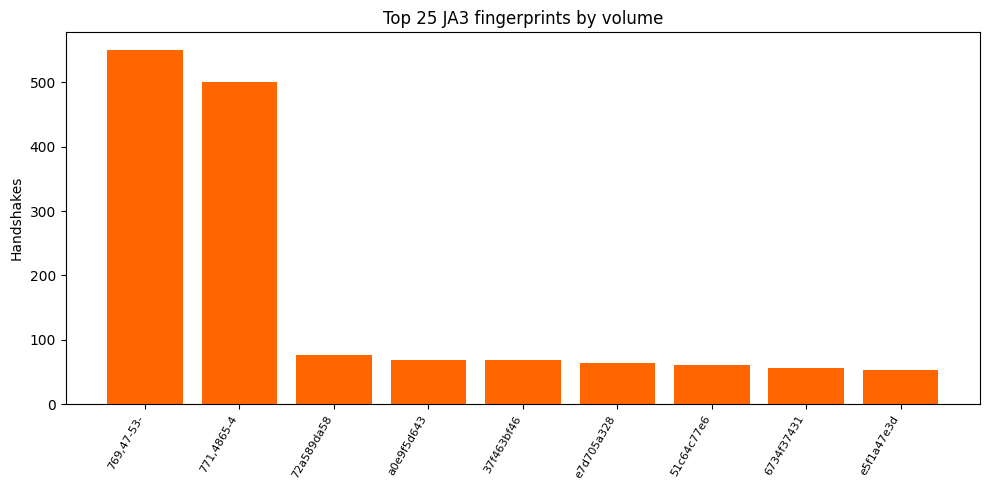

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
ja3_sorted = ja3.sort_values('Handshakes', ascending=False).head(25)
plt.bar(range(len(ja3_sorted)), ja3_sorted['Handshakes'], color='#FF6600')
plt.xticks(range(len(ja3_sorted)), [j[:10] for j in ja3_sorted['Ja3']], rotation=60, ha='right', fontsize=8)
plt.ylabel('Handshakes'); plt.title('Top 25 JA3 fingerprints by volume')
plt.tight_layout(); plt.show()

## Match against the known-bad list

Same list the `Gigamon_JA3_Threat_Match` MCP tool uses — kept inline here for explorability.

In [4]:
KNOWN_BAD = {
  'e7d705a3286e19ea42f587b344ee6865': 'Trickbot',
  'a0e9f5d64349fb13191bc781f81f42e1': 'Emotet',
  '37f463bf4616ecd445d4a1937da06e19': 'Adwind RAT',
  '72a589da586844d7f0818ce684948eea': 'Tor browser',
  '51c64c77e60f3980eea90869b68c58a8': 'Sliver C2',
  'e5f1a47e3d5d8b3f3e2b4f53a3c6a32f': 'Cobalt Strike',
}
ja3['ThreatLabel'] = ja3['Ja3'].map(KNOWN_BAD)
hits = ja3[ja3['ThreatLabel'].notnull()]
hits

,Ja3,Handshakes,Sources,SampleSnis,SampleIssuers,ThreatLabel
2,72a589da586844d7f0818ce684948eea,77,5,"[""unknown.bad-example.test"",""legacy-api.contos...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]",Tor browser
3,a0e9f5d64349fb13191bc781f81f42e1,69,5,"[""unknown.bad-example.test"",""portal.contoso.co...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]",Emotet
4,37f463bf4616ecd445d4a1937da06e19,68,5,"[""unknown.bad-example.test"",""portal.contoso.co...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]",Adwind RAT
5,e7d705a3286e19ea42f587b344ee6865,64,5,"[""unknown.bad-example.test"",""legacy-api.contos...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]",Trickbot
6,51c64c77e60f3980eea90869b68c58a8,61,5,"[""legacy-api.contoso-lab.example"",""unknown.bad...","[""CN=Contoso Legacy CA,O=Contoso,C=US""]",Sliver C2
8,e5f1a47e3d5d8b3f3e2b4f53a3c6a32f,53,5,"[""portal.contoso.com"",""legacy-api.contoso-lab....","[""CN=Contoso Legacy CA,O=Contoso,C=US""]",Cobalt Strike


## Drill: who's hitting Cobalt Strike?

In [5]:
if not hits.empty:
    target = hits.iloc[0]['Ja3']
    detail = kql(f'''
GigamonCcfMcpDemo_CL
| where ssl_fingerprint_ja3 == "{target}"
| project TimeGenerated, src_ip, dst_ip, dst_port, ssl_common_name, ssl_certificate_dn_issuer, total_bytes
| order by TimeGenerated desc
| take 50
''')
    display(detail)
else:
    print('No known-bad JA3 hits in current window.')

,TimeGenerated,src_ip,dst_ip,dst_port,ssl_common_name,ssl_certificate_dn_issuer,total_bytes
0,2026-05-13 17:24:12.304000+00:00,10.42.10.15,10.42.20.50,3389,legacy-api.contoso-lab.example,"CN=Contoso Legacy CA,O=Contoso,C=US",8640
1,2026-05-13 17:23:40.580000+00:00,10.42.20.50,203.0.113.20,1195,portal.contoso.com,"CN=Contoso Legacy CA,O=Contoso,C=US",2400
2,2026-05-13 17:22:59.722000+00:00,172.16.5.11,198.51.100.77,1195,portal.contoso.com,"CN=Contoso Legacy CA,O=Contoso,C=US",996225
3,2026-05-13 17:22:49.987000+00:00,172.16.5.11,10.42.40.8,445,unknown.bad-example.test,"CN=Contoso Legacy CA,O=Contoso,C=US",996225
4,2026-05-13 17:22:34.452000+00:00,172.16.5.11,10.42.30.21,22,legacy-api.contoso-lab.example,"CN=Contoso Legacy CA,O=Contoso,C=US",996225
5,2026-05-13 17:22:28.438000+00:00,172.16.5.11,10.42.40.8,1194,portal.contoso.com,"CN=Contoso Legacy CA,O=Contoso,C=US",2400
6,2026-05-13 17:21:54.638000+00:00,10.42.10.23,198.51.100.77,3389,portal.contoso.com,"CN=Contoso Legacy CA,O=Contoso,C=US",45351
7,2026-05-13 17:21:38.741000+00:00,192.0.2.45,10.42.30.21,6881,portal.contoso.com,"CN=Contoso Legacy CA,O=Contoso,C=US",2400
8,2026-05-13 17:20:35.360000+00:00,172.16.5.11,10.42.20.50,53,portal.contoso.com,"CN=Contoso Legacy CA,O=Contoso,C=US",2400
9,2026-05-13 17:17:49.692000+00:00,172.16.5.11,10.42.30.21,53,unknown.bad-example.test,"CN=Contoso Legacy CA,O=Contoso,C=US",9016500
